# Predicción de precios de autos con Machine Learning

**Proyecto final - Entrenamiento y optimización de modelos de Machine Learning**

Este notebook retoma la pre-entrega basada en el análisis exploratorio de precios de autos y la extiende hacia un flujo completo de Machine Learning: preparación de datos, ingeniería de atributos, validación cruzada, optimización de hiperparámetros, modelos ensemble y selección final del modelo con mejor performance.

## Índice

1. Abstracto, motivación y audiencia
2. Problema de negocio y preguntas de análisis
3. Carga y revisión inicial de datos
4. Análisis exploratorio de datos (EDA)
5. Ingeniería de atributos y preprocesamiento
6. Entrenamiento y validación cruzada
7. Optimización de hiperparámetros
8. Ensemble modeling y selección final
9. Interpretación, residuos y conclusiones

## 1. Abstracto: motivación y audiencia

El mercado automotor combina información técnica, comercial y de uso del vehículo. Para una persona que compra o vende un auto, estimar un precio razonable puede ser difícil porque el valor depende de múltiples factores: marca, modelo, antigüedad, kilometraje, condición, tipo de combustible, transmisión y características del motor.

El objetivo de este proyecto es construir un modelo de Machine Learning capaz de predecir el precio de un auto a partir de sus características. La motivación principal es transformar el análisis exploratorio de la pre-entrega en una herramienta predictiva que ayude a tomar mejores decisiones.

**Audiencia beneficiada:**

- Compradores y vendedores que necesitan una referencia objetiva de precio.
- Concesionarios o equipos comerciales que quieren comparar unidades de manera más consistente.
- Analistas de datos que buscan entender qué variables aportan más información al valor de un auto.
- Estudiantes de Data Science que necesitan un caso completo de EDA, feature engineering, entrenamiento, optimización y selección de modelos.

## 2. Preguntas y problema que buscamos resolver

La problemática principal se formula como un problema de **regresión supervisada**:

> Dadas las características de un auto, predecir su precio (`Price`).

Preguntas guía:

1. ¿Cómo se distribuye el precio de los autos?
2. ¿Existen valores faltantes, duplicados o rangos atípicos que puedan afectar el modelo?
3. ¿Qué variables numéricas se relacionan con el precio?
4. ¿Hay diferencias de precio según marca, modelo, combustible, transmisión o condición?
5. ¿Mejora la performance al crear variables como antigüedad del auto o kilometraje anual?
6. ¿Qué modelo presenta mejor performance usando validación cruzada?
7. ¿La optimización de hiperparámetros mejora el modelo base?
8. ¿Un modelo ensemble mejora o iguala el rendimiento de los modelos individuales?

**Variable objetivo:** `Price`.

**Métricas principales:** RMSE y MAE, porque están expresadas en unidades monetarias y permiten interpretar el error promedio. También se reporta R2 para evaluar la proporción de variabilidad explicada por el modelo.

## 3. Carga de librerías

Se utilizan librerías estándar para análisis de datos, visualización y Machine Learning. El proyecto evita depender de librerías externas no esenciales, por lo que los modelos se implementan con `scikit-learn`.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor, VotingRegressor
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import Ridge
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
    from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere scikit-learn. En Colab suele estar instalado; "
        "en un entorno local instala la dependencia con: pip install scikit-learn"
    ) from exc

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

## 4. Carga de datos

El archivo `datos.txt` contiene la URL pública del dataset. Si el archivo existe en el entorno local, se lee desde allí; si no existe, se usa la URL de respaldo. También se contempla un archivo CSV local como respaldo para entornos donde Python tenga problemas de certificados SSL.

In [2]:
DEFAULT_DATA_URL = "https://raw.githubusercontent.com/ryc343/Data-ScienceII-2/refs/heads/main/car_price_prediction_.csv"

datos_path = Path("datos.txt")
if datos_path.exists():
    data_source = datos_path.read_text(encoding="utf-8").strip() or DEFAULT_DATA_URL
else:
    data_source = DEFAULT_DATA_URL

local_csv = Path("car_price_prediction_.csv")

print("Fuente de datos:", data_source)
try:
    df_raw = pd.read_csv(data_source)
except Exception as exc:
    if local_csv.exists():
        print(f"No se pudo leer la URL ({type(exc).__name__}). Se usa respaldo local: {local_csv}")
        df_raw = pd.read_csv(local_csv)
    else:
        raise
df_raw.head()

Fuente de datos: https://raw.githubusercontent.com/ryc343/Data-ScienceII-2/refs/heads/main/car_price_prediction_.csv
No se pudo leer la URL (URLError). Se usa respaldo local: car_price_prediction_.csv


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.30,Petrol,Manual,114832,New,"26,613.92",Model X
1,2,BMW,2018,4.40,Electric,Manual,143190,Used,"14,679.61",5 Series
2,3,Audi,2013,4.50,Electric,Manual,181601,New,"44,402.61",A4
3,4,Tesla,2011,4.10,Diesel,Automatic,68682,New,"86,374.33",Model Y
4,5,Ford,2009,2.60,Diesel,Manual,223009,Like New,"73,577.10",Mustang


## 5. Revisión inicial

Se revisan dimensiones, columnas, tipos de datos y una muestra inicial del dataset para confirmar que la información cargada coincide con el problema de precios de autos.

In [3]:
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]:,}")
print("\nColumnas:")
print(list(df_raw.columns))

display(df_raw.head())

df_raw.info()

Filas: 2,500
Columnas: 10

Columnas:
['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model']


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.30,Petrol,Manual,114832,New,"26,613.92",Model X
1,2,BMW,2018,4.40,Electric,Manual,143190,Used,"14,679.61",5 Series
2,3,Audi,2013,4.50,Electric,Manual,181601,New,"44,402.61",A4
3,4,Tesla,2011,4.10,Diesel,Automatic,68682,New,"86,374.33",Model Y
4,5,Ford,2009,2.60,Diesel,Manual,223009,Like New,"73,577.10",Mustang


<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB


### Diccionario de variables

- `Car ID`: identificador único del registro. No se usará como predictor porque no describe características del auto.
- `Brand`: marca del vehículo.
- `Year`: año del vehículo.
- `Engine Size`: tamaño del motor.
- `Fuel Type`: tipo de combustible.
- `Transmission`: tipo de transmisión.
- `Mileage`: kilometraje acumulado.
- `Condition`: condición declarada del auto.
- `Model`: modelo del vehículo.
- `Price`: precio del auto, variable objetivo.

## 6. Limpieza mínima y calidad de datos

Antes del EDA y del modelado se normalizan nombres y valores de texto, se fuerzan tipos numéricos en las columnas esperadas y se revisan nulos y duplicados.

In [4]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

text_columns = df.select_dtypes(include=["object", "string"]).columns
for col in text_columns:
    df[col] = df[col].map(lambda value: value.strip() if isinstance(value, str) else value)

numeric_columns_expected = ["Car ID", "Year", "Engine Size", "Mileage", "Price"]
for col in numeric_columns_expected:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

quality_summary = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (df.isna().mean() * 100).round(2),
    "únicos": df.nunique(dropna=True),
})

display(quality_summary)
print("Registros duplicados:", df.duplicated().sum())

,tipo,nulos,nulos_%,únicos
Car ID,int64,0,0.00,2500
Brand,str,0,0.00,7
Year,int64,0,0.00,24
Engine Size,float64,0,0.00,51
Fuel Type,str,0,0.00,4
Transmission,str,0,0.00,2
Mileage,int64,0,0.00,2490
Condition,str,0,0.00,3
Price,float64,0,0.00,2499
Model,str,0,0.00,28


Registros duplicados: 0


In [5]:
print("Resumen numérico:")
display(df.describe().T)

print("Resumen categórico:")
display(df.describe(include=["object", "string"]).T)

Resumen numérico:


,count,mean,std,min,25%,50%,75%,max
Car ID,"2,500.00","1,250.50",721.83,1.00,625.75,"1,250.50","1,875.25","2,500.00"
Year,"2,500.00","2,011.63",6.99,"2,000.00","2,005.00","2,012.00","2,018.00","2,023.00"
Engine Size,"2,500.00",3.47,1.43,1.00,2.20,3.40,4.70,6.00
Mileage,"2,500.00","149,749.84","87,919.95",15.00,"71,831.50","149,085.00","225,990.50","299,967.00"
Price,"2,500.00","52,638.02","27,295.83","5,011.27","28,908.49","53,485.24","75,838.53","99,982.59"


Resumen categórico:


,count,unique,top,freq
Brand,2500,7,Toyota,374
Fuel Type,2500,4,Diesel,655
Transmission,2500,2,Manual,1308
Condition,2500,3,Used,855
Model,2500,28,Fiesta,103


## 7. Análisis exploratorio de datos (EDA)

En esta sección se analiza la distribución de la variable objetivo, la relación entre precio y variables numéricas, y las diferencias de precio entre categorías. Este paso ayuda a detectar patrones, valores atípicos y posibles transformaciones útiles para el modelo.

### Distribución de precios

Se grafica el precio en escala original y en escala logarítmica para observar concentración, dispersión y posibles colas largas.

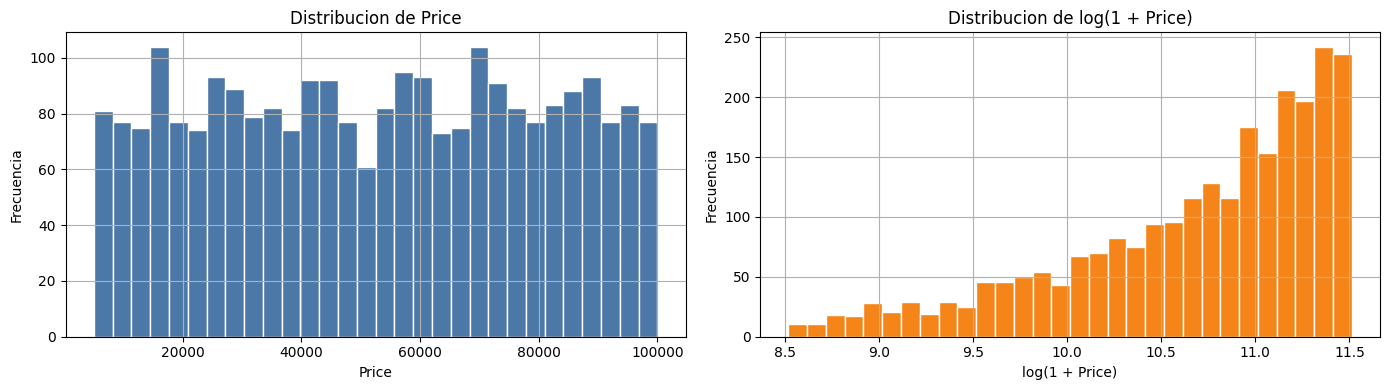

,Price
0.01,"6,289.14"
0.05,"9,747.49"
0.25,"28,908.49"
0.50,"53,485.24"
0.75,"75,838.53"
0.95,"94,769.06"
0.99,"98,701.96"


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["Price"].dropna(), bins=30, color="#4C78A8", edgecolor="white")
axes[0].set_title("Distribución de Price")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["Price"].dropna()), bins=30, color="#F58518", edgecolor="white")
axes[1].set_title("Distribución de log(1 + Price)")
axes[1].set_xlabel("log(1 + Price)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

display(df["Price"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("Price"))

### Precio según variables numéricas

Se revisa la relación entre precio, año, kilometraje y tamaño del motor.

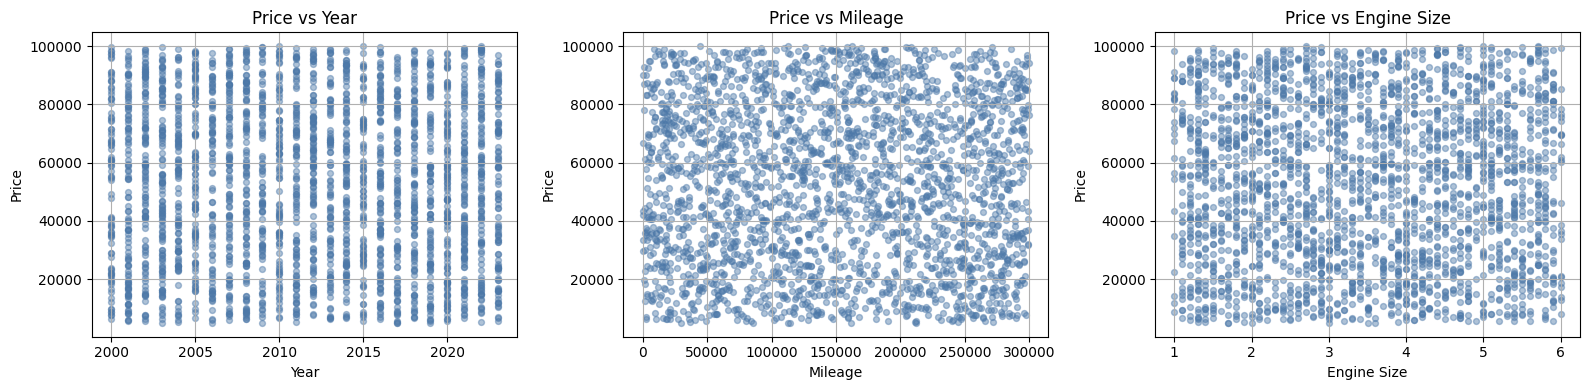

In [7]:
numeric_predictors = ["Year", "Mileage", "Engine Size"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, numeric_predictors):
    ax.scatter(df[feature], df["Price"], alpha=0.45, s=18, color="#4C78A8")
    ax.set_title(f"Price vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

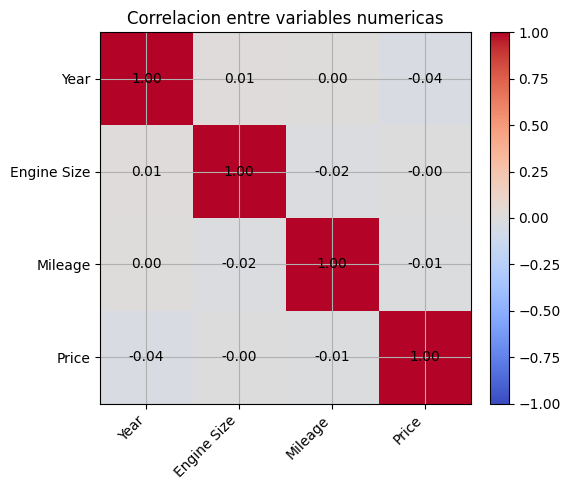

In [8]:
corr_columns = ["Year", "Engine Size", "Mileage", "Price"]
corr = df[corr_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlación entre variables numéricas")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Precio por variables categóricas

Se comparan distribuciones de precio por combustible, transmisión y condición. También se revisan precios promedio por marca.

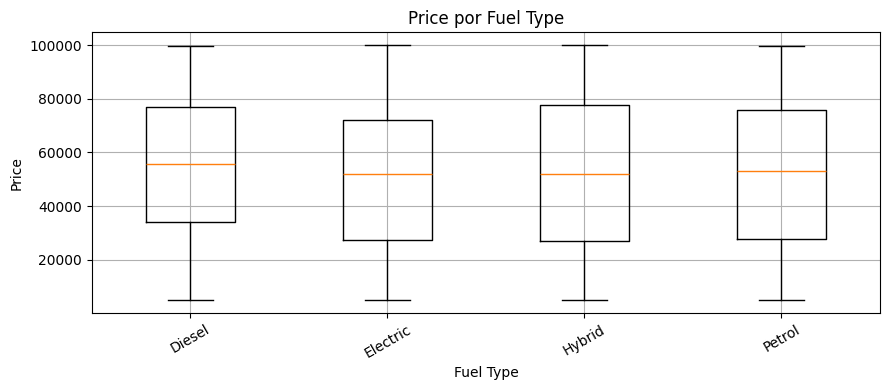

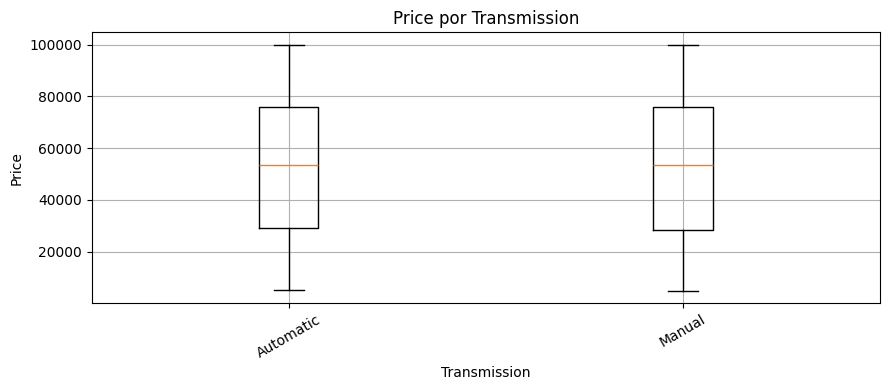

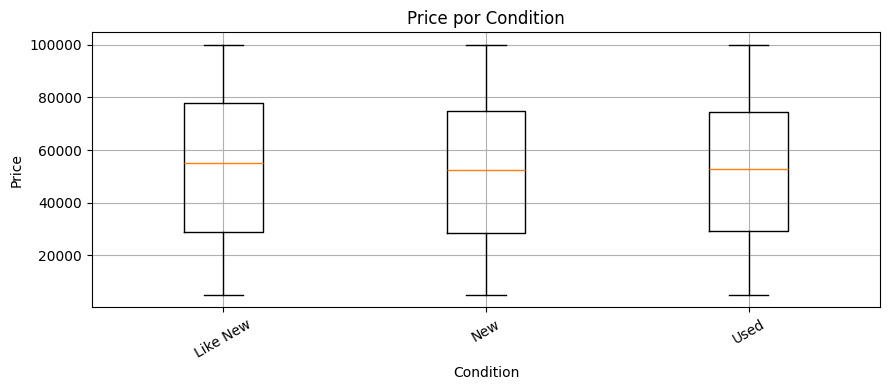

In [9]:
def plot_box_by_category(data, category, target="Price"):
    groups = []
    labels = []
    for label, values in data.groupby(category)[target]:
        groups.append(values.dropna())
        labels.append(label)

    fig, ax = plt.subplots(figsize=(9, 4))
    try:
        ax.boxplot(groups, tick_labels=labels, showfliers=False)
    except TypeError:
        ax.boxplot(groups, labels=labels, showfliers=False)
    ax.set_title(f"{target} por {category}")
    ax.set_xlabel(category)
    ax.set_ylabel(target)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

for category in ["Fuel Type", "Transmission", "Condition"]:
    plot_box_by_category(df, category)

,cantidad,promedio,mediana
Brand,,,
BMW,358,"54,157.11","57,690.36"
Tesla,348,"53,475.55","54,157.65"
Mercedes,353,"53,191.09","53,425.53"
Toyota,374,"52,078.73","52,087.34"
Honda,352,"52,050.28","53,315.17"
Audi,368,"51,953.42","49,153.57"
Ford,347,"51,593.25","50,475.25"


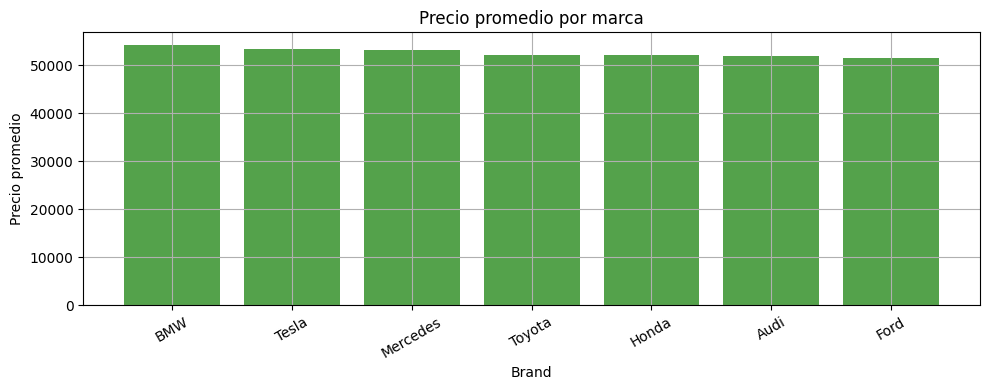

In [10]:
brand_stats = (
    df.groupby("Brand")["Price"]
    .agg(cantidad="count", promedio="mean", mediana="median")
    .sort_values("promedio", ascending=False)
)

display(brand_stats)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(brand_stats.index, brand_stats["promedio"], color="#54A24B")
ax.set_title("Precio promedio por marca")
ax.set_xlabel("Brand")
ax.set_ylabel("Precio promedio")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Hallazgos preliminares del EDA

- El dataset contiene variables numéricas y categóricas relevantes para modelar el precio.
- No se observan valores faltantes en la versión actual del archivo, aunque el pipeline igualmente incluye imputación para robustez.
- `Car ID` funciona como identificador y no debe usarse como variable explicativa.
- Las relaciones lineales simples entre variables numéricas y precio pueden ser débiles; por eso conviene probar modelos no lineales y ensemble.
- Las variables categóricas como marca, modelo, tipo de combustible, transmisión y condición pueden aportar información mediante encoding.

La página del dataset no documenta explícitamente si los datos son reales o sintéticos. Por ese motivo, la selección del modelo debe basarse en validación cruzada y métricas, no solo en interpretaciones intuitivas.

## 8. Ingeniería de atributos

Se crean variables derivadas para representar mejor la edad y el uso del vehículo:

- `Car_Age`: antigüedad del auto respecto a un año de referencia.
- `Mileage_per_Year`: kilometraje promedio anual.
- `Log_Mileage`: transformación logarítmica del kilometraje para reducir escala y dispersión.
- `Engine_Size_x_Age`: interacción simple entre tamaño de motor y antigüedad.

Luego se separa la variable objetivo y se define un preprocesamiento con imputación, escalado numérico y One-Hot Encoding para variables categóricas.

In [11]:
df_model = df.copy()

REFERENCE_YEAR = max(2026, int(df_model["Year"].max()))
df_model["Car_Age"] = (REFERENCE_YEAR - df_model["Year"]).clip(lower=0)
df_model["Mileage_per_Year"] = df_model["Mileage"] / df_model["Car_Age"].replace(0, 1)
df_model["Log_Mileage"] = np.log1p(df_model["Mileage"])
df_model["Engine_Size_x_Age"] = df_model["Engine Size"] * df_model["Car_Age"]

if "Car ID" in df_model.columns:
    df_model = df_model.drop(columns=["Car ID"])

display(df_model.head())
print("Columnas para modelado:")
print(list(df_model.columns))

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Car_Age,Mileage_per_Year,Log_Mileage,Engine_Size_x_Age
0,Tesla,2016,2.30,Petrol,Manual,114832,New,"26,613.92",Model X,10,"11,483.20",11.65,23.00
1,BMW,2018,4.40,Electric,Manual,143190,Used,"14,679.61",5 Series,8,"17,898.75",11.87,35.20
2,Audi,2013,4.50,Electric,Manual,181601,New,"44,402.61",A4,13,"13,969.31",12.11,58.50
3,Tesla,2011,4.10,Diesel,Automatic,68682,New,"86,374.33",Model Y,15,"4,578.80",11.14,61.50
4,Ford,2009,2.60,Diesel,Manual,223009,Like New,"73,577.10",Mustang,17,"13,118.18",12.31,44.20


Columnas para modelado:
['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model', 'Car_Age', 'Mileage_per_Year', 'Log_Mileage', 'Engine_Size_x_Age']


In [12]:
TARGET = "Price"

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)
print("Variable objetivo:", TARGET)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    sparse_threshold=0,
)

def build_model_pipeline(model):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

Variables numéricas: ['Year', 'Engine Size', 'Mileage', 'Car_Age', 'Mileage_per_Year', 'Log_Mileage', 'Engine_Size_x_Age']
Variables categóricas: ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']
Variable objetivo: Price


## 9. Entrenamiento, testeo y validación cruzada

Se separa un conjunto de test para evaluación final y se comparan varios modelos con validación cruzada K-Fold. La comparación inicial incluye un modelo lineal regularizado y varios modelos ensemble.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2000, 12) Test: (500, 12)


In [14]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": rmse_scorer,
    "R2": "r2",
}

cv_rows = []
for model_name, model in base_models.items():
    pipeline = build_model_pipeline(model)
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_rows.append({
        "Modelo": model_name,
        "MAE_cv": -scores["test_MAE"].mean(),
        "RMSE_cv": -scores["test_RMSE"].mean(),
        "R2_cv": scores["test_R2"].mean(),
        "RMSE_cv_std": scores["test_RMSE"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("RMSE_cv").reset_index(drop=True)
display(cv_results)

,Modelo,MAE_cv,RMSE_cv,R2_cv,RMSE_cv_std
0,Ridge,"23,907.25","27,619.86",-0.03,470.30
1,GradientBoosting,"24,050.08","27,926.41",-0.05,617.03
2,RandomForest,"24,187.70","28,071.18",-0.07,520.27
3,ExtraTrees,"25,118.50","29,629.54",-0.19,570.54


## 10. Optimización de hiperparámetros

Se utiliza `RandomizedSearchCV` para optimizar un `RandomForestRegressor`. La búsqueda se realiza sobre el conjunto de entrenamiento y evalúa combinaciones mediante validación cruzada.

In [15]:
rf_pipeline = build_model_pipeline(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
)

param_distributions = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 6, 10, 16, 24],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring=rmse_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print("Mejor RMSE CV:", -rf_search.best_score_)
print("Mejores hiperparámetros:")
display(pd.Series(rf_search.best_params_).to_frame("valor"))

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Mejor RMSE CV: 27344.407859767398
Mejores hiperparámetros:


,valor
model__n_estimators,200
model__min_samples_split,10
model__min_samples_leaf,1
model__max_features,sqrt
model__max_depth,6


## 11. Ensemble modeling y evaluación en test

Siguiendo la idea del notebook de Titanic, se construye un modelo ensemble final con `VotingRegressor`, combinando modelos de árboles. Luego se comparan los candidatos finales en el conjunto de test usando MAE, RMSE y R2.

In [16]:
best_rf_params = {
    key.replace("model__", ""): value
    for key, value in rf_search.best_params_.items()
}

rf_optimized_model = RandomForestRegressor(
    **best_rf_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

voting_regressor = VotingRegressor(estimators=[
    ("rf", rf_optimized_model),
    ("extra", ExtraTreesRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)),
    ("gb", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

final_candidates = {
    "RandomForest optimizado": rf_search.best_estimator_,
    "ExtraTrees": build_model_pipeline(ExtraTreesRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)),
    "GradientBoosting": build_model_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    "VotingRegressor ensemble": build_model_pipeline(voting_regressor),
}

final_rows = []
fitted_models = {}

for model_name, pipeline in final_candidates.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    fitted_models[model_name] = pipeline
    final_rows.append({
        "Modelo": model_name,
        "MAE_test": mean_absolute_error(y_test, predictions),
        "RMSE_test": rmse(y_test, predictions),
        "R2_test": r2_score(y_test, predictions),
    })

final_results = pd.DataFrame(final_rows).sort_values("RMSE_test").reset_index(drop=True)
display(final_results)

selected_model_name = final_results.loc[0, "Modelo"]
selected_model = fitted_models[selected_model_name]

print(f"Modelo seleccionado por menor RMSE en test: {selected_model_name}")

,Modelo,MAE_test,RMSE_test,R2_test
0,RandomForest optimizado,"23,708.15","27,520.12",0.00
1,VotingRegressor ensemble,"23,911.36","27,925.54",-0.03
2,GradientBoosting,"23,820.41","28,029.23",-0.04
3,ExtraTrees,"25,157.41","29,639.07",-0.16


Modelo seleccionado por menor RMSE en test: RandomForest optimizado


## 12. Interpretación del modelo seleccionado

Si el modelo seleccionado permite calcular importancia de variables, se muestran las variables más influyentes. Para modelos ensemble como `VotingRegressor`, se promedia la importancia de los estimadores que la exponen.

,feature,importance
4,num__Mileage_per_Year,0.12
2,num__Mileage,0.12
5,num__Log_Mileage,0.11
6,num__Engine_Size_x_Age,0.10
1,num__Engine Size,0.09
0,num__Year,0.07
3,num__Car_Age,0.06
14,cat__Fuel Type_Diesel,0.03
44,cat__Model_Mustang,0.02
38,cat__Model_GLA,0.02


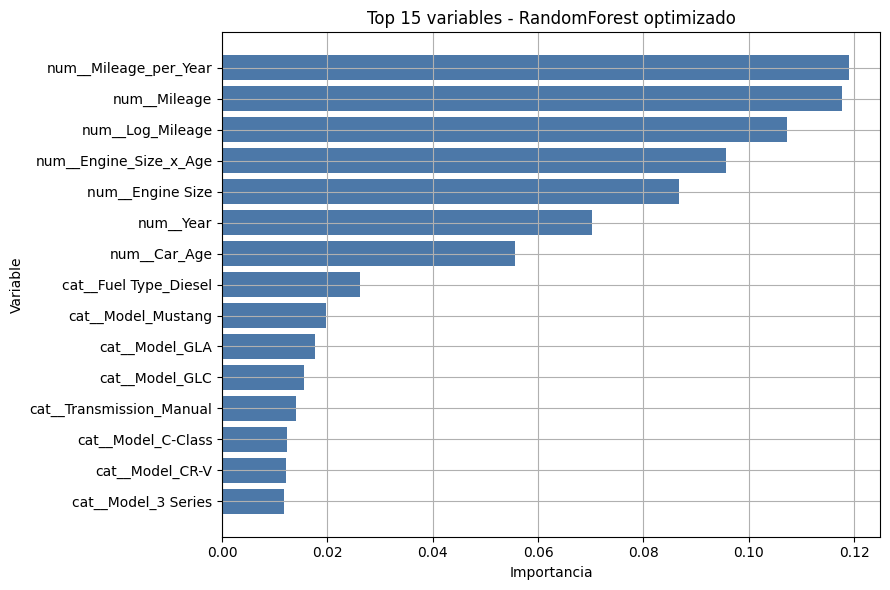

In [17]:
def get_feature_names_from_pipeline(pipeline):
    preprocessor_step = pipeline.named_steps["preprocessor"]
    try:
        return preprocessor_step.get_feature_names_out()
    except Exception:
        transformed = preprocessor_step.transform(X_train.head(1))
        return np.array([f"feature_{i}" for i in range(transformed.shape[1])])

feature_names = get_feature_names_from_pipeline(selected_model)
model_component = selected_model.named_steps["model"]
importance_values = None

if hasattr(model_component, "feature_importances_"):
    importance_values = model_component.feature_importances_
elif hasattr(model_component, "estimators_"):
    importances = [
        estimator.feature_importances_
        for estimator in model_component.estimators_
        if hasattr(estimator, "feature_importances_")
    ]
    if importances:
        importance_values = np.mean(importances, axis=0)
elif hasattr(model_component, "coef_"):
    importance_values = np.abs(np.ravel(model_component.coef_))

if importance_values is None:
    print("El modelo seleccionado no expone importancia de variables de forma directa.")
else:
    importances_df = (
        pd.DataFrame({"feature": feature_names, "importance": importance_values})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    display(importances_df)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(importances_df["feature"][::-1], importances_df["importance"][::-1], color="#4C78A8")
    ax.set_title(f"Top 15 variables - {selected_model_name}")
    ax.set_xlabel("Importancia")
    ax.set_ylabel("Variable")
    plt.tight_layout()
    plt.show()

## 13. Análisis de residuos

El análisis de residuos ayuda a revisar si los errores del modelo se distribuyen de manera razonable o si existen zonas de precio donde el modelo falla más.

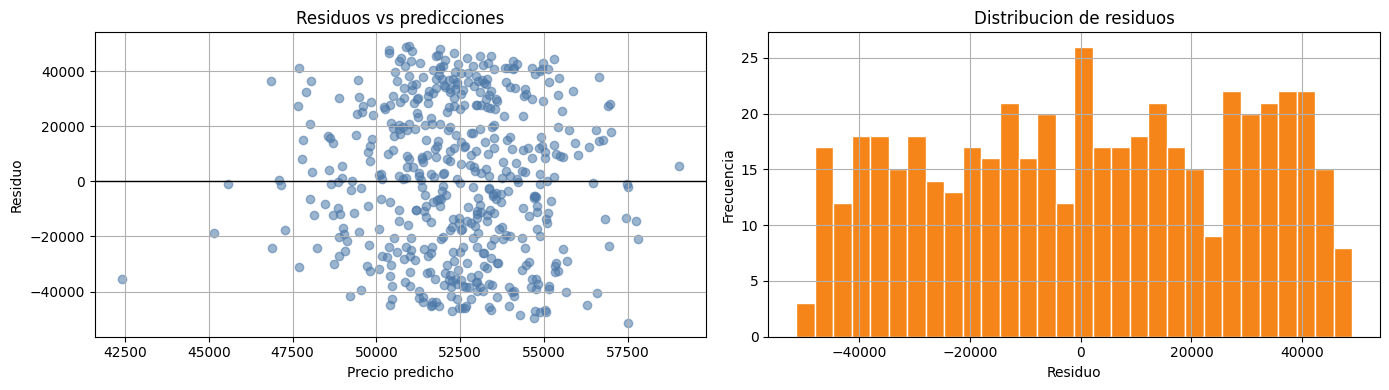

,residuos
count,500.00
mean,953.09
std,"27,531.15"
min,"-51,332.88"
25%,"-23,264.91"
50%,"1,574.89"
75%,"26,809.50"
max,"49,004.56"


In [18]:
selected_predictions = selected_model.predict(X_test)
residuals = y_test - selected_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(selected_predictions, residuals, alpha=0.55, color="#4C78A8")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuos vs predicciónes")
axes[0].set_xlabel("Precio predicho")
axes[0].set_ylabel("Residuo")

axes[1].hist(residuals, bins=30, color="#F58518", edgecolor="white")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Residuo")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

residual_summary = pd.Series(residuals).describe().to_frame("residuos")
display(residual_summary)

## 14. Selección final y conclusiones

La selección del modelo se realiza con base en el menor RMSE sobre el conjunto de test, revisando también MAE y R2. RMSE penaliza más los errores grandes, mientras que MAE indica el error absoluto promedio en unidades monetarias.

Conclusiones esperadas al ejecutar el notebook:

- Si el modelo ensemble o el Random Forest optimizado logra el menor RMSE, se justifica seleccionar un modelo no lineal porque puede capturar interacciones entre marca, modelo, condición, kilometraje y antigüedad.
- Si el R2 resulta bajo, no necesariamente significa que el pipeline esté mal construido; puede indicar que el dataset tiene relaciones débiles o sintéticas entre predictores y precio, algo que ya se observó en el EDA de la pre-entrega.
- La ingeniería de atributos permite enriquecer la información original con variables como antigüedad y kilometraje anual.
- El uso de validación cruzada reduce el riesgo de seleccionar un modelo solo por un resultado puntual de train/test.
- La optimización de hiperparámetros permite comparar una versión ajustada contra modelos base y contra un ensemble final.

El modelo final recomendado es el que se imprime en la sección de evaluación en test como **modelo seleccionado por menor RMSE**.

In [19]:
print("Resumen final de modelos evaluados:")
display(final_results)

best_row = final_results.iloc[0]
print("Modelo seleccionado:", best_row["Modelo"])
print(f"MAE test: {best_row['MAE_test']:,.2f}")
print(f"RMSE test: {best_row['RMSE_test']:,.2f}")
print(f"R2 test: {best_row['R2_test']:,.4f}")

Resumen final de modelos evaluados:


,Modelo,MAE_test,RMSE_test,R2_test
0,RandomForest optimizado,"23,708.15","27,520.12",0.00
1,VotingRegressor ensemble,"23,911.36","27,925.54",-0.03
2,GradientBoosting,"23,820.41","28,029.23",-0.04
3,ExtraTrees,"25,157.41","29,639.07",-0.16


Modelo seleccionado: RandomForest optimizado
MAE test: 23,708.15
RMSE test: 27,520.12
R2 test: 0.0003
